# Data Exploration
---

This notebook is an exploration of the data used in the benchmark in our classical AND quantum models. I will be using the [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) library for this since it is very common for graph classification. I will be exporting this data as a PyTorch Geometric Data object for use in the models.

The goal of this notebook is to understand the structure of the dataset before training any models. In particular, I want to inspect:
- node features
- edge structure
- class labels
- dataset size
- how the data is represented as a PyTorch Geometric Data object

In [33]:
# Main Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree

# Utilities
from pathlib import Path

print('All imports done and torch version is', torch.__version__)

All imports done and torch version is 2.12.1+cpu


I decieded to work on the `Plantoid` Homogeneous Datasets, for this specifically I will be using the Cora dataset since it is a very common dataset for graph classification. See the [PyTorch Geometric documentation](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.Planetoid.html#torch_geometric.datasets.Planetoid) for more information on the dataset.

A litte more about the Cora and adjacent datasets:

The Cora, CiteSeer, and PubMed datasets in `torch_geometric.datasets.Planetoid` come from the citation-network benchmark introduced in Revisiting Semi-Supervised Learning with Graph Embeddings by *Yang, Cohen, and Salakhutdinov*.

This paper is the canonical reference for the Planetoid dataset family and the standard train/validation/test splits commonly used in graph learning experiments.

In [49]:
dataset_name = 'Cora'

# Keep the root path explicit so we can check for the cached processed file.
root = Path(r'C:\GitHub\My Repos\qml-graph-benchmark\data')

processed_file = root / dataset_name / 'processed' / 'data.pt'

if not processed_file.exists():
	print('Processed cache not found, creating dataset:', dataset_name)
else:
	print('Processed cache found, loading dataset:', dataset_name)

dataset = Planetoid(root=str(root), name=dataset_name)

Processed cache found, loading dataset: Cora


So I wanted to draw the graph network from the graph dataset and I found a library called `networkx` that can do this for us. I will be using this to plot the graph to see if the data is skewed.

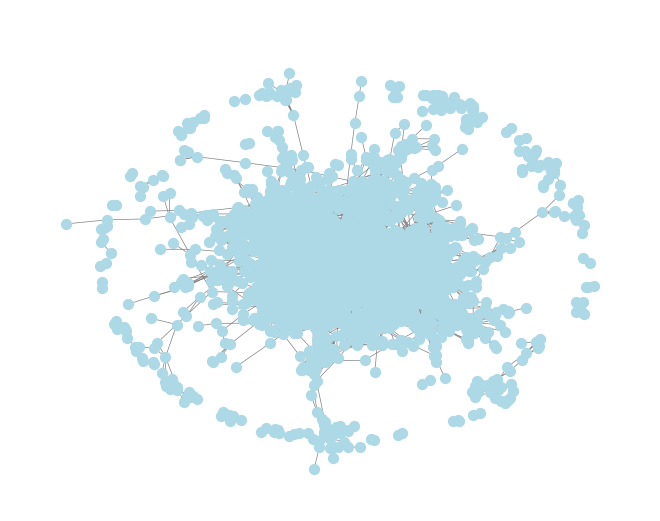

In [55]:
import networkx as nx
from torch_geometric.utils import to_networkx

data = dataset[0]
G = to_networkx(data, to_undirected = True)

plt.Figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed = 42)

nx.draw(
	G,
	pos,
	with_labels = False,
	node_size = 50,
	node_color = 'lightblue',
	edge_color = 'gray',
	width = 0.5
)

plt.title('Cora Graph')
plt.show()


Now that we have our data in a PyTorch Geometric Data object, we can start to explore it! Since we are working with graph classification, we will be looking at the node features, edge structure, and class labels.

First I wanted to get a breif overview of the data, how many edges, features, nodes, etc.

In [ ]:
data = dataset[0]

# General info
summary = pd.DataFrame([
	['Dataset', dataset_name],
	# ['Graph object', str(data)],
	['Nodes', data.num_nodes],
	['Features per node', data.num_node_features],
	['Edges', data.num_edges],
	['Classes', dataset.num_classes],
])
summary.columns = ['Metric', 'Value']
print(summary.to_string(index=False))

# Data details
print('\nFeature matrix shape:', tuple(data.x.shape))
print('Edge index shape:', tuple(data.edge_index.shape))

# Class distribution
label_counts = torch.bincount(data.y, minlength=dataset.num_classes)
label_summary = pd.DataFrame({
	'Class': list(range(dataset.num_classes)),
	'Count': label_counts.tolist(),
})
print('\nClass distribution:')
print(label_summary.to_string(index=False))

# Train / Val / Test split
print('\nTrain / Val / Test nodes:')

split_summary = pd.DataFrame([
	['Train', int(data.train_mask.sum())],
	['Validation', int(data.val_mask.sum())],
	['Test', int(data.test_mask.sum())],
], columns=['Split', 'Count'])
print(split_summary.to_string(index=False))

           Metric Value
          Dataset  Cora
            Nodes  2708
Features per node  1433
            Edges 10556
          Classes     7

Feature matrix shape: (2708, 1433)
Edge index shape: (2, 10556)

Class distribution:
 Class  Count
     0    351
     1    217
     2    418
     3    818
     4    426
     5    298
     6    180

Train / Val / Test nodes:
     Split  Count
     Train    140
Validation    500
      Test   1000


Now some data analysis to get a better feel for the data. I wanted to make a class distribution plot and a node degree distribution plot to see if the data is skewed.

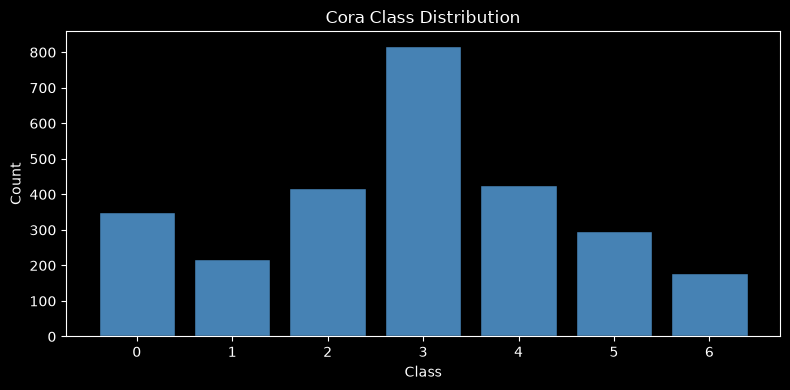

In [37]:
# Class distribution
plt.figure(figsize=(8, 4))
plt.bar(range(dataset.num_classes), label_counts.tolist(), color='steelblue', edgecolor='black')
plt.xticks(range(dataset.num_classes))
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Cora Class Distribution')
plt.tight_layout()
plt.show()

Notice the catagorical is almost bell shaped like with class 3 having the highest count. This is a good indicator that the data is not too skewed. Class 6 is the least represented class.

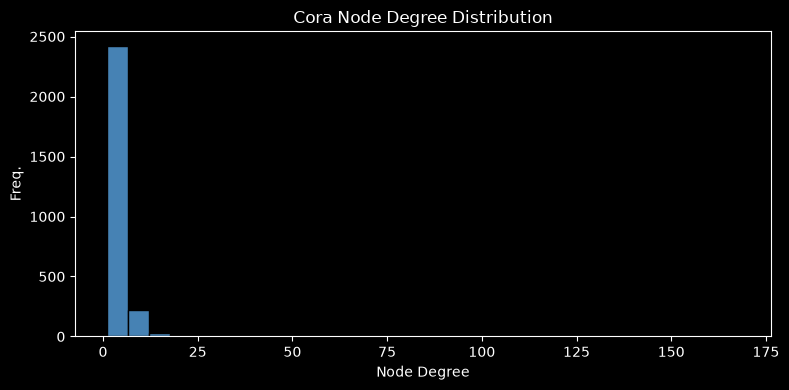

In [36]:
# Node Degree
deg = degree(data.edge_index[0], num_nodes=data.num_nodes)

plt.figure(figsize=(8, 4))
plt.hist(deg, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Node Degree')
plt.ylabel('Freq.')
plt.title('Cora Node Degree Distribution')
plt.tight_layout()
plt.show()


We can see in the node degree that we are dealing with a right-skewed distribution with a long tail. This graph does indeed indecate that the data is very skewed! The node-degree distribution is strongly right-skewed with a long tail. Most nodes have relatively few connections, while a small number of nodes act as highly connected hubs. This type of heavy-tailed distribution is common in real-world citation and social networks.

My interpretation:
- lots of papers only cite or are cited by a few others
- a small number of nodes act like hubs

Min nonzero features per node: 1
Max nonzero features per node: 30


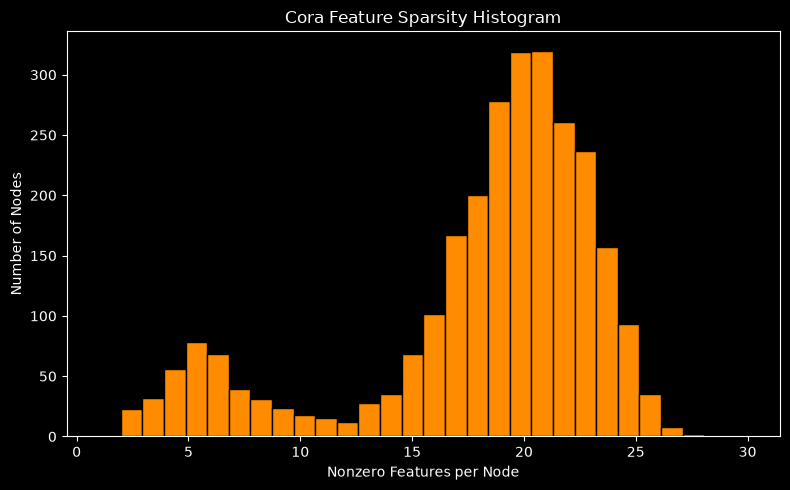

In [46]:
# Count how many features are nonzero for each node
nonzero_per_node = (data.x > 0).sum(dim=1)  # sum over features

print('Min nonzero features per node:', nonzero_per_node.min().item())
print('Max nonzero features per node:', nonzero_per_node.max().item())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_per_node.numpy(), bins=30, color='darkorange', edgecolor='black')
plt.xlabel('Nonzero Features per Node')
plt.ylabel('Number of Nodes')
plt.title('Cora Feature Sparsity Histogram')
plt.tight_layout()
plt.show()